# Tutorial 6: Visualization

The result of analysis can be visualized using `mlgidBASE.plot_analysis_result()` function. First, create the mlgidBASE class instance and run the analysis:

In [1]:
from mlgidbase import mlgidBASE
filename = '../../example/BA2PbI4.h5'
analysis = mlgidBASE(filename=filename)
analysis.run_detection()
analysis.run_fitting()
analysis.run_matching(
    cif_prepr = r'../../example/prepr_cifs.pickle',
    peaks_type='segments')

INFO - Loading model
INFO - Using the GPU for inference
INFO - Saved detected peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - Saved fitted peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0
INFO - Saved matched peaks to file: ../../example/BA2PbI4.h5, entry: entry_0000, frame: 0


Before plotting, default plot parameters can be set:

In [2]:
from pprint import pprint
pprint(analysis.set_plot_defaults.__doc__)

('\n'
 '        Sets the default settings for various parts of a Matplotlib plot, '
 'including font sizes, gridlines,\n'
 '        legend, figure properties, and line styles. The function configures '
 'the default style for future\n'
 '        plots created with Matplotlib.\n'
 '\n'
 '        Parameters:\n'
 '        - font_size (int): Default font size for text elements (e.g., title, '
 'labels, ticks).\n'
 '        - axes_titlesize (int): Font size for axes titles.\n'
 '        - axes_labelsize (int): Font size for axes labels (x and y).\n'
 '        - grid (bool): Whether or not to display gridlines (True/False).\n'
 "        - grid_color (str): Color of the gridlines (e.g., 'gray', 'black').\n"
 "        - grid_linestyle (str): Line style of the gridlines (e.g., '--', "
 "'-', ':').\n"
 '        - grid_linewidth (float): Width of the gridlines.\n'
 '        - xtick_labelsize (int): Font size for x-axis tick labels.\n'
 '        - ytick_labelsize (int): Font size for y-axis tick l

In [3]:
analysis.set_plot_defaults(cmap='inferno',
                           savefig_dpi=600)

Run visualization:

---
#### **Minimal Code Example**


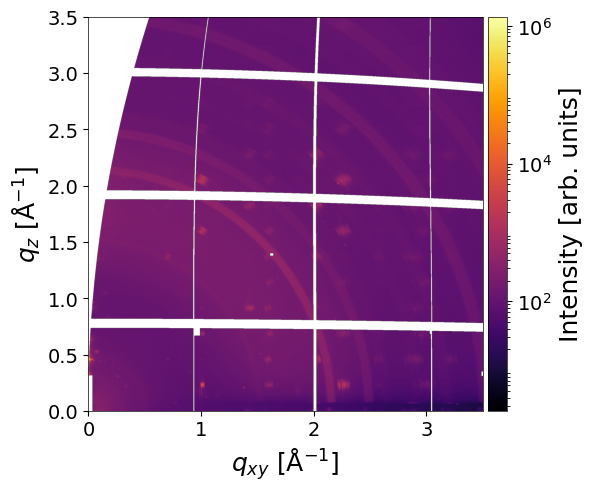

In [4]:
analysis.plot_analysis_results()

---

### Parameters

- `entry` (str) — Data file entry to process. Defaults to `None` (process all entries). OPTIONAL
- `frame_num` (int or List[int]) — Frame number(s) within each entry to process. Defaults to `None` (all frames). OPTIONAL
- `clims` (tuple or list) — Minimum and maximum limits for the color scale. OPTIONAL
- `xlim` (tuple or list) — Horizontal axis limits. Defaults to `None` (full image). OPTIONAL
- `ylim` (tuple or list) — Vertical axis limits. Defaults to `None` (full image). OPTIONAL
- `plot_result` (bool) — Whether to display the result. Defaults to `True`. OPTIONAL
- `save_fig` (bool) — Whether to save the figure. Defaults to `False`. OPTIONAL
- `path_to_save_fig` (str) — Path to save the figure. Defaults to `'img.png'`. OPTIONAL
- `detected_params` (dict) — Visualization parameters for detected peaks. OPTIONAL
- `fitted_params` (dict) — Visualization parameters for fitted peaks. OPTIONAL
- `matched_params` (dict) — Visualization parameters for matched peaks. OPTIONAL

---

---
### Examples

1. Plot the detected boxes:


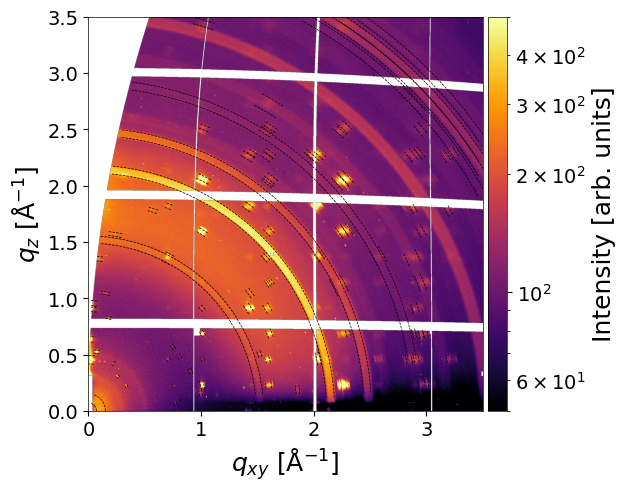

In [10]:
# Visualization settings for detected peaks
detected_params = {
    'line_width': 0.5,     # width of the bounding box lines
    'line_style': "--",    # style of the bounding box lines
    'line_color': "black", # color of the bounding box lines
    'plot_id': False,      # whether to display peak IDs
    'text_color': 'white', # color of the ID labels
    'text_size': 6,        # font size of the ID labels
    'plot': True           # enable/disable plotting of detected peaks
}

# Plot analysis results with custom detected peak visualization
analysis.plot_analysis_results(detected_params=detected_params,
                               entry = 'entry_0000',
                               frame_num=0,
                               clims=(50, 5e2),)

2. Plot fitted peaks (both rings and segments) with peak ID

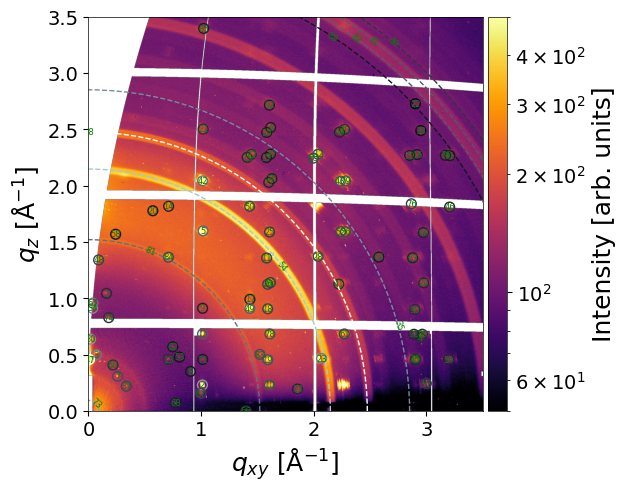

In [11]:
# Visualization settings for fitted peaks
fitted_params = {
    'plot_segments': True,     # show fitted peak positions as markers
    'marker': 'o',             # marker shape for peaks
    'marker_size': 50,         # size of the markers
    'marker_facecolor': "none",# fill color of markers (none = transparent)
    'marker_edgecolor': "bone",# edge color of markers
    'plot_rings': True,        # draw fitted rings
    'line_width': 1,           # width of ring lines
    'line_style': "--",        # style of ring lines
    'line_color': "bone",      # color of ring lines
    'plot_id': True,           # display peak IDs
    'text_color': 'green',     # color of ID labels
    'text_size': 6,            # font size of ID labels
    'plot': True               # enable/disable plotting
}

# Plot analysis results with custom fitted peak visualization
analysis.plot_analysis_results(
    fitted_params=fitted_params,
    entry='entry_0000',  # select entry
    frame_num=0,         # select frame
    clims=(50, 5e2),     # color map
)

3. Plot solutions for peak matching

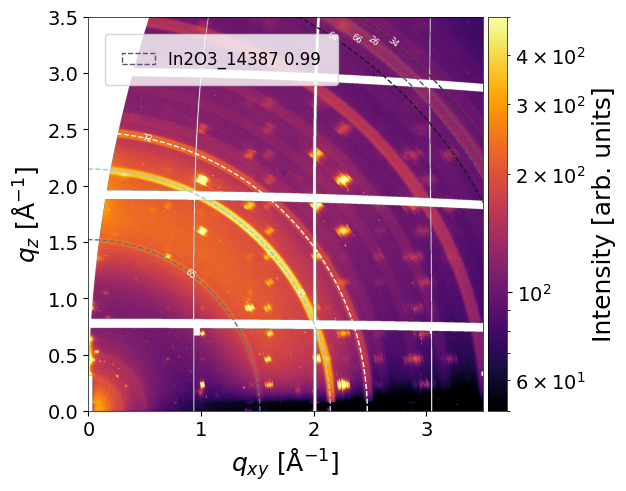

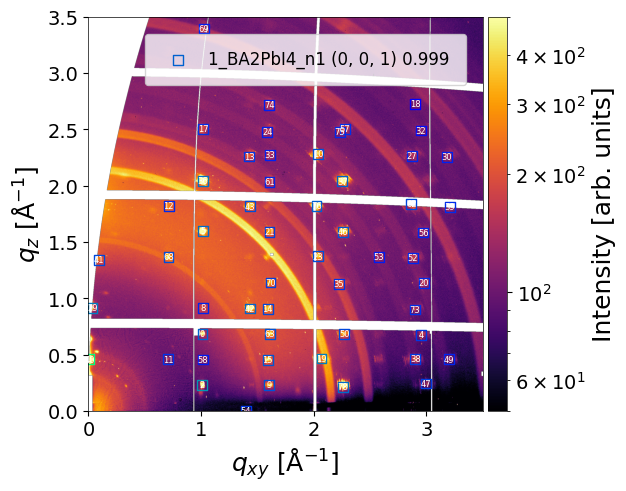

In [17]:
# Visualization settings for matched peaks (multiple structures in solution)
matched_params = {
    'plot_segments': True,         # show matched peak positions
    'marker': ['s', 's', 's'],     # marker shapes for each structure
    'marker_size': [50, 50, 50],   # marker sizes for each structure
    'marker_facecolor': ["none", "none", "none"],  # marker fill colors
    'marker_edgecolor': ["winter", 'blue', 'green'], # marker edge colors per structure
    'plot_rings': True,            # draw matched rings
    'line_width': [1, 1, 1],       # line widths for each structure
    'line_style': ["--", "--", "--"], # line styles for each structure
    'line_color': ["bone", 'blue', 'bone'], # line colors per structure
    'plot_id': True,              # display peak IDs
    'text_color': 'white',         # color of ID labels
    'text_size': 8,                # font size of ID labels
    'legend': True,                # show legend for multiple structures
    'plot': True,                 # enable/disable plotting of matched peaks
}

# Plot analysis results with selected matched peak visualization
analysis.plot_analysis_results(
    matched_params=matched_params,
    entry='entry_0000',  # select entry
    frame_num=0,          # select frame
    clims=(50, 5e2),     # color map
)

**Note:** The legend contains information about the matched CIF file, the corresponding contact plane, and the matching probability. Marker and ring color proportional to the peak fitted amplitude according to the provided color map.